<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_038_validation_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 38/365 — Validation Curves
## How do we know whether a hyperparameter is too small or too large?

Over the last few days we learned about hyperparameters, Grid Search, and Randomized Search.

Today we look at something more visual: the **Validation Curve**.

A validation curve shows how model performance changes as one hyperparameter changes.

For this experiment, we use Ridge Regression on the real scikit-learn Diabetes dataset and vary `alpha`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import validation_curve, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge


## 1. Load the real dataset


In [2]:
data = load_diabetes(as_frame=True)
X = data.data.copy()
y = data.target.copy()

print("Dataset shape:", X.shape)


Dataset shape: (442, 10)


## 2. Build the Pipeline

Scaling stays inside the Pipeline so every cross-validation fold fits the scaler only on that fold's training portion.


In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])


## 3. Choose alpha values to inspect

Instead of searching only for the best value, we observe the pattern across a wide range.


In [4]:
alphas = np.logspace(-3, 3, 13)
print(alphas)


[1.00000000e-03 3.16227766e-03 1.00000000e-02 3.16227766e-02
 1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03]


## 4. Calculate training and validation performance

For each `alpha`, we calculate both training RMSE and validation RMSE using 5-fold cross-validation.


In [5]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_scores, validation_scores = validation_curve(
    estimator=pipeline,
    X=X,
    y=y,
    param_name="ridge__alpha",
    param_range=alphas,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

train_rmse = -train_scores.mean(axis=1)
validation_rmse = -validation_scores.mean(axis=1)

results = pd.DataFrame({
    "Alpha": alphas,
    "Train RMSE": train_rmse,
    "Validation RMSE": validation_rmse
})

display(results.round(4))


,Alpha,Train RMSE,Validation RMSE
0,0.0010,53.3156,54.8489
1,0.0032,53.3156,54.8488
2,0.0100,53.3156,54.8485
3,0.0316,53.3156,54.8476
4,0.1000,53.3158,54.8449
5,0.3162,53.3176,54.8380
6,1.0000,53.3295,54.8271
7,3.1623,53.3749,54.8230
8,10.0000,53.4581,54.8165
9,31.6228,53.5973,54.8094


## 5. Find the best validation alpha


In [6]:
best_index = np.argmin(validation_rmse)
best_alpha = alphas[best_index]

print("Best alpha by validation RMSE:", best_alpha)
print("Best validation RMSE:", round(validation_rmse[best_index], 2))


Best alpha by validation RMSE: 31.622776601683793
Best validation RMSE: 54.81


## 6. Visual — the validation curve

This is the main visual for today.

The training and validation curves show how regularization strength changes model fit and generalization.


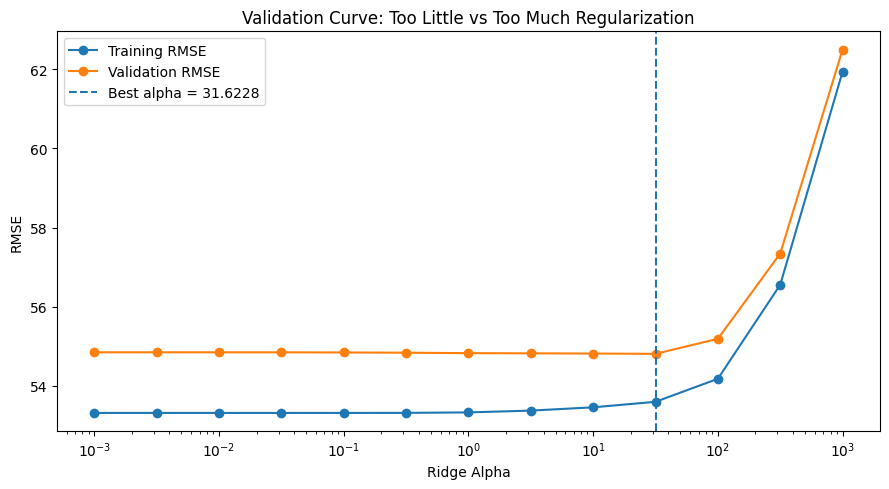

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    alphas,
    train_rmse,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    alphas,
    validation_rmse,
    marker="o",
    label="Validation RMSE"
)

plt.axvline(
    best_alpha,
    linestyle="--",
    label=f"Best alpha = {best_alpha:g}"
)

plt.xscale("log")
plt.xlabel("Ridge Alpha")
plt.ylabel("RMSE")
plt.title("Validation Curve: Too Little vs Too Much Regularization")
plt.legend()
plt.tight_layout()
plt.show()


## How to read the graph

**Small alpha**
- weak regularization
- model has more freedom
- training error may be lower

**Moderate alpha**
- validation performance may improve
- better balance between fitting and regularization

**Very large alpha**
- strong regularization
- coefficients become heavily constrained
- training and validation error can rise
- this can indicate underfitting


## What does this experiment teach?

- A single “best hyperparameter” value hides the larger story.
- Validation curves show how model behavior changes across hyperparameter values.
- Training performance alone is not enough to choose a hyperparameter.
- Very strong regularization can cause underfitting.
- The useful region is where validation error is lowest, not where training error is lowest.

> **Hyperparameter tuning is not only about finding a number. It is about understanding how that number changes model behavior.**


## References

- scikit-learn — Validation curves: https://scikit-learn.org/stable/modules/learning_curve.html#validation-curve
- scikit-learn — validation_curve: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html
- scikit-learn — Ridge: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
- scikit-learn — Diabetes dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
